In [2]:
#np.save('../x_train.npy', x_train)
#np.save('../y_train.npy', y_train)

from sklearn.metrics import classification_report
from termcolor import colored
import seaborn as sns
from sklearn.metrics import confusion_matrix
from keras.models import load_model
from matplotlib import pyplot as plt
from keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from sklearn.model_selection import train_test_split
import pandas as pd
# import csv
import os
# import sys
import cv2
import numpy as np
import tensorflow
from scipy.ndimage.filters import gaussian_filter
from keras.callbacks import ModelCheckpoint
from skimage.transform import rotate
import keract

echogenicity_path='Echogenicity_model.h5'
margin_path='Margin_model.h5'
macrocalcification_path='Macrocalcification_Model.h5'
punctate_echogenic_foci_path='Punctate_Echogenic_Foci_model.h5'

echogenicity_model = load_model(echogenicity_path)
margin_model = load_model(margin_path)
macrocalcification_model = load_model(macrocalcification_path)
punctate_echogenic_foci_model = load_model(punctate_echogenic_foci_path)
print("Loaded models from disk")

def get_class_prediction(model, x):
    pred = model.predict(x)
    if pred.shape[1] == 1:
        return (pred>0.5).astype(np.int8).squeeze(axis=-1)
    else:
        return pred.argmax(axis=1)

def present(predicted, characteristic):
    if(characteristic=="echo"):
        predicted+=1
    elif(characteristic=="margin"):
        for i in range(len(predicted)):
            if predicted[i]!=0:
                predicted[i]+=1
    elif(characteristic=="macro"):
        1
    elif(characteristic=="punctate"):
        for i in range(len(predicted)):
            if predicted[i]==1:
                predicted[i]=3
    return predicted

Loaded models from disk


NameError: name 'plt' is not defined

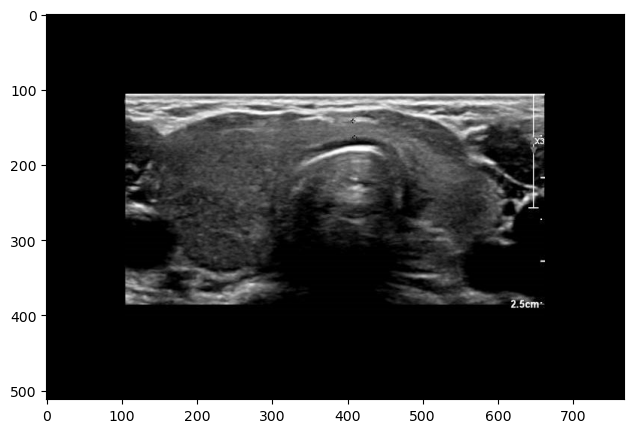

                          Predicted score
Echogenicity                            2
Margin                                  2
Macrocalcification                      1
Punctate echogenic foci                 3
Total                                   8


In [3]:
image_path='test.png'
image_array = load_image(image_path)
image = crop_image(image_array, (512,768))
plt.figure(figsize=(18, 5))
plt.imshow(image, 'gray')
plt.grid(False)
plt.show()

image = tf.expand_dims(image, axis=0)
image = tf.expand_dims(image, axis=-1)

predicted_echo=get_class_prediction(echogenicity_model, image)
predicted_margin=get_class_prediction(margin_model, image)
predicted_macro=get_class_prediction(macrocalcification_model, image)
predicted_punctate=get_class_prediction(punctate_echogenic_foci_model, image)

predicted_echo=present(predicted_echo,"echo")
predicted_margin=present(predicted_margin,"margin")
predicted_macro=present(predicted_macro,"macro")
predicted_punctate=present(predicted_punctate,"punctate")

predicted_total=predicted_echo[0]+predicted_margin[0]+predicted_macro[0]+predicted_punctate[0]

print("                          Predicted score")
print("Echogenicity              "+f"{predicted_echo[0]:15}")
print("Margin                    "+f"{predicted_margin[0]:15}")
print("Macrocalcification        "+f"{predicted_macro[0]:15}")
print("Punctate echogenic foci   "+f"{predicted_punctate[0]:15}")
print("Total                     "+f"{predicted_total:15}")

In [ ]:
from tkinter import *
from tkinter.ttk import *
from tkinter.filedialog import askopenfile 
from tkinter import filedialog
from PIL import Image, ImageTk
import tkinter
import tkinter as tk

import time

root = Tk()
root.title('AI Analysis of Thyroid Ultrasound Image')
root.geometry('1000x1000') 

# Add image file
image = Image.open('Background.png')
image.thumbnail((700,500))
bg = ImageTk.PhotoImage(image,master=root)
# Create Canvas
canvas1 = Canvas( master=root, width = 700,
                 height = 500)
canvas1.grid()
# Display image
canvas1.create_image( 0, 0, image = bg, 
                     anchor = "nw")

name=""


plt.rcParams['axes.grid'] = False
plt.rcParams["figure.figsize"] = (24, 12)

#Cropping Constants

BINARY_THRESHOLD = 1
RUN_THRESHOLD = 0.14
MIN_HEIGHT = 300

#Artifacts Constants

ARTIFACT_INTENSITY = 220

def load_image(image_path):
    img = cv2.imread(image_path, 1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img_rgb

def crop_image(image_array, window_size):
    ultrasound_image = find_ultrasound_image(image_array)
    cropped_image = standardize_size(ultrasound_image, window_size)
    return cropped_image

def remove_artifacts(cropped_image):
    artifact_flags = cropped_image >= ARTIFACT_INTENSITY
    artifact_idx = np.where(artifact_flags)
    artifact_idx_list = []
    for i, y in enumerate(artifact_idx[0]):
        x = artifact_idx[1][i]
        artifact_idx_list.append((y, x, cropped_image[y, x]))
    artifact_idx_list.sort(key=lambda tup: tup[2], reverse=False)
    for y, x, _ in artifact_idx_list:
        local_region = cropped_image[(y-1):(y+2), (x-1):(x+2)]
        background_mean = np.mean(sorted(local_region.flatten())[:6])
        cropped_image[y, x] = background_mean
    return cropped_image

def find_ultrasound_image(image_array):
    binary_mask = np.zeros(image_array.shape)
    binary_mask[image_array > BINARY_THRESHOLD] = 1.
    row_mean = np.mean(binary_mask, axis=0)
    col_mean = np.mean(binary_mask, axis=1)
    row_runs = get_bidirectional_runs(row_mean)
    col_runs = get_bidirectional_runs(col_mean)
    row_indices = np.where(row_runs >= np.max(row_runs)*0.75)[0]
    left_bound = row_indices[0]
    right_bound = row_indices[-1]
    col_indices = np.where(col_runs >= np.max(col_runs)*0.75)[0]
    up_bound = col_indices[0]
    down_bound = max(col_indices[-1], up_bound + MIN_HEIGHT)
    cropped_image = image_array[up_bound:down_bound, left_bound:right_bound]
    return cropped_image

def standardize_size(ultrasound_image, window_size):
    resized_image = np.zeros(window_size)
    horizontal_boundary = int((window_size[1] - ultrasound_image.shape[1])/2)
    vertical_boundary = int((window_size[0] - ultrasound_image.shape[0])/2)
    resized_image[vertical_boundary:(vertical_boundary+ultrasound_image.shape[0]),
                  horizontal_boundary:(horizontal_boundary+ultrasound_image.shape[1])] = ultrasound_image
    return resized_image

def get_bidirectional_runs(mean_vector):
    forward_runs = get_runs(mean_vector)
    backward_runs = get_runs(mean_vector[::-1])[::-1]
    bidirectional_runs = forward_runs + backward_runs
    return bidirectional_runs

def get_runs(numeric_vector):
    runs = np.empty(len(numeric_vector), dtype=np.int16)
    curr = 0
    for i, x in enumerate(numeric_vector):
        if x > RUN_THRESHOLD:
            curr += 1
        else:
            curr = 0
        runs[i] = curr
    return runs

def represents_int(s):
    try:
        int(s)
        return True
    except ValueError:
        return False






def UploadAction(event=None):
    filename = filedialog.askopenfilename()
    print("Selected:",filename)
    global name
    name=filename
    
def confirm(event=None):
    adhar2 = Label(
        root, 
        wraplength=300,
        text='Selected: '+name
    )
    adhar2.grid(row=5, column=0, padx=10)
    
#     image_path=name
#     image_array = load_image(image_path)
#     image = crop_image(image_array, (512,768))
#     img =  ImageTk.PhotoImage(image=Image.fromarray(image))
#     print(img)

#     canvas = Canvas(root,width=300,height=300)
#     canvas.grid()
#     canvas.create_image(20,20, anchor="nw", image=img)
    array = np.ones((40,40))*150
    img =  ImageTk.PhotoImage(image=Image.fromarray(array))

    canvas = tk.Canvas(root,width=300,height=300)
    canvas.grid(row=20)
    canvas.create_image(20,20, image=img)
    
#     # Create a photoimage object of the image in the path
#     image1 = Image.open(name)
#     test = ImageTk.PhotoImage(image1)

#     label1 = tkinter.Label(image=test)
#     label1.image = test

#     # Position image
#     label1.place(x=500, y=500)

    
adhar = Label(
    root, 
    text='Upload ultrasound image'
    )
adhar.grid(row=0, column=0, padx=10)


adharbtn = Button(
    root, 
    text ='Choose File', 
    command = UploadAction
    ) 
adharbtn.grid(row=0, column=1)

adharbtn1 = Button(
    root, 
    text ='Confirm', 
    command = confirm
    ) 
adharbtn1.grid(row=3, column=1)



# Button for closing
exit_button = Button(root, text="Exit", command=root.destroy)
exit_button.grid(pady=20)





# image_path='test.png'
# image_array = load_image(image_path)
# image = crop_image(image_array, (512,768))
# plt.figure(figsize=(18, 5))
# plt.imshow(image, 'gray')
# plt.grid(False)
# plt.show()

root.mainloop()

In [ ]:
import tkinter as tk
from tkinter import filedialog

def UploadAction(event=None):
    filename = filedialog.askopenfilename()
    print('Selected:', filename)

root = tk.Tk()
button = tk.Button(root, text='Open', command=UploadAction)
button.pack()

root.mainloop()

Selected: 
Selected: /Users/sikaihuang/Desktop/School/Project/Thyroid_Ultrasound/thyroid_modeling/notebooks/Sikai_FINAL/test.png


In [3]:
print("HI")

HI
